# 🌧️ Rain Prediction using Machine Learning

## Business Understanding

PT AIGRA EON Indonesia merupakan perusahaan yang bergerak di bidang Smart Farming. Salah satu tantangan utama dalam sektor pertanian adalah ketidakpastian cuaca yang dapat mempengaruhi aktivitas penanaman, penyiraman, hingga panen.

Pada proyek ini akan dibangun model klasifikasi untuk memprediksi apakah besok akan terjadi hujan (RainTomorrow) berdasarkan data cuaca historis Australia.

Tujuan utama proyek bukan hanya memperoleh akurasi tinggi, tetapi juga membangun pipeline machine learning yang baik mulai dari eksplorasi data, preprocessing, feature engineering, pelatihan model, hingga evaluasi dan interpretasi hasil.

# Import Library

In [76]:
# ==========================================================
# 1. Import Library
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Load Dataset

Pada tahap ini dataset dimuat ke dalam Python menggunakan pandas. Selanjutnya dilakukan pemeriksaan awal terhadap struktur data seperti jumlah baris, jumlah kolom, tipe data, serta statistik deskriptif. Langkah ini penting untuk memahami karakteristik dataset sebelum dilakukan preprocessing maupun pemodelan.

In [77]:
# ==========================================================
# 2. Load Dataset
# ==========================================================

df = pd.read_csv("../data/weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [78]:
# Mengetahui Ukuran Dataset
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")

Jumlah baris : 145,460
Jumlah kolom : 23


In [79]:
# Melihat Nama Kolom
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. Date
2. Location
3. MinTemp
4. MaxTemp
5. Rainfall
6. Evaporation
7. Sunshine
8. WindGustDir
9. WindGustSpeed
10. WindDir9am
11. WindDir3pm
12. WindSpeed9am
13. WindSpeed3pm
14. Humidity9am
15. Humidity3pm
16. Pressure9am
17. Pressure3pm
18. Cloud9am
19. Cloud3pm
20. Temp9am
21. Temp3pm
22. RainToday
23. RainTomorrow


In [80]:
# Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [81]:
# Statistik Deskriptif
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,145460,3436,2013-11-12,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,145460,49,Canberra,3436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MinTemp,143975.0,NaN,NaN,NaN,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,NaN,NaN,NaN,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,NaN,NaN,NaN,2.360918,8.47806,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,NaN,NaN,NaN,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,NaN,NaN,NaN,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustDir,135134,16,W,9915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindGustSpeed,135197.0,NaN,NaN,NaN,40.03523,13.607062,6.0,31.0,39.0,48.0,135.0
WindDir9am,134894,16,N,11758,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
# Cek Duplikasi
duplicate = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate}")

Jumlah data duplikat : 0


In [83]:
# Ringkasan Dataset 
summary = pd.DataFrame({
    "Jumlah Baris": [df.shape[0]],
    "Jumlah Kolom": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate": [df.duplicated().sum()]
})

summary

,Jumlah Baris,Jumlah Kolom,Missing Values,Duplicate
0,145460,23,343248,0


# Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk memahami karakteristik dataset sebelum dilakukan preprocessing dan pemodelan. Analisis meliputi distribusi target, missing values, distribusi fitur numerik, korelasi antar variabel, serta identifikasi outlier.

## Distribusi Target

In [84]:
# ==========================================================
# Distribusi Target
# ==========================================================

target_counts = df["RainTomorrow"].value_counts(dropna=False)

print(target_counts)

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64


In [85]:
# Persentase Target
target_percentage = (
    df["RainTomorrow"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

target_percentage

RainTomorrow
No     75.84
Yes    21.91
NaN     2.25
Name: proportion, dtype: float64

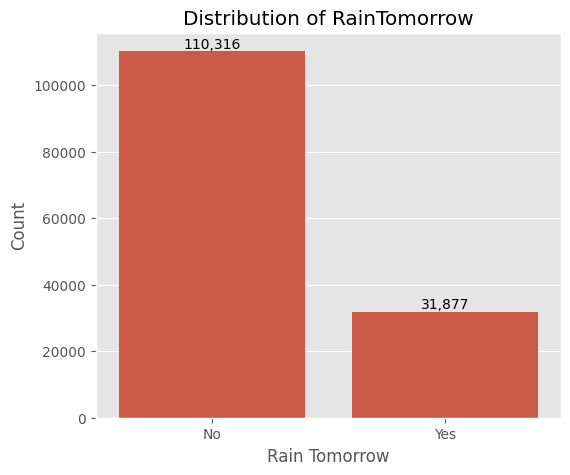

In [86]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="RainTomorrow",
    order=["No","Yes"]
)

plt.title("Distribution of RainTomorrow")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

## Missing Value Handling

In [87]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing_count = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": (missing_count / len(df) * 100).round(2)
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Count,Missing Percentage
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [88]:
# Tampilkan hanya kolom yang memiliki Missing Value

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df

,Missing Count,Missing Percentage
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


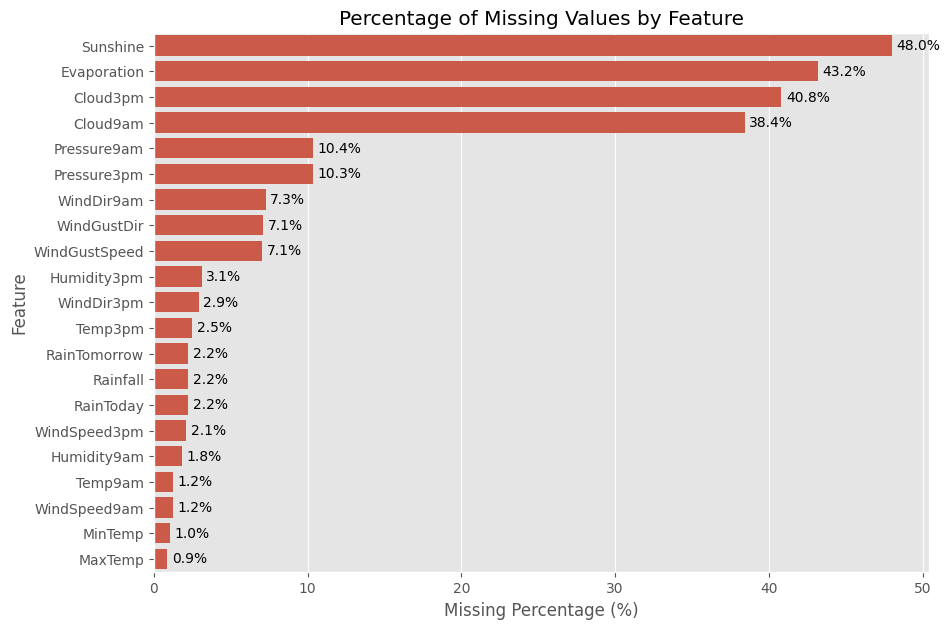

In [89]:
plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=missing_df.reset_index(),
    x="Missing Percentage",
    y="index",
)

for i, value in enumerate(missing_df["Missing Percentage"]):
    ax.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.show()

## Analisis Fitur Numerik

In [90]:
# ==========================================================
# Numerical Features
# ==========================================================

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

print("Jumlah fitur numerik :", len(numerical_features))
print(numerical_features.tolist())

Jumlah fitur numerik : 16
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


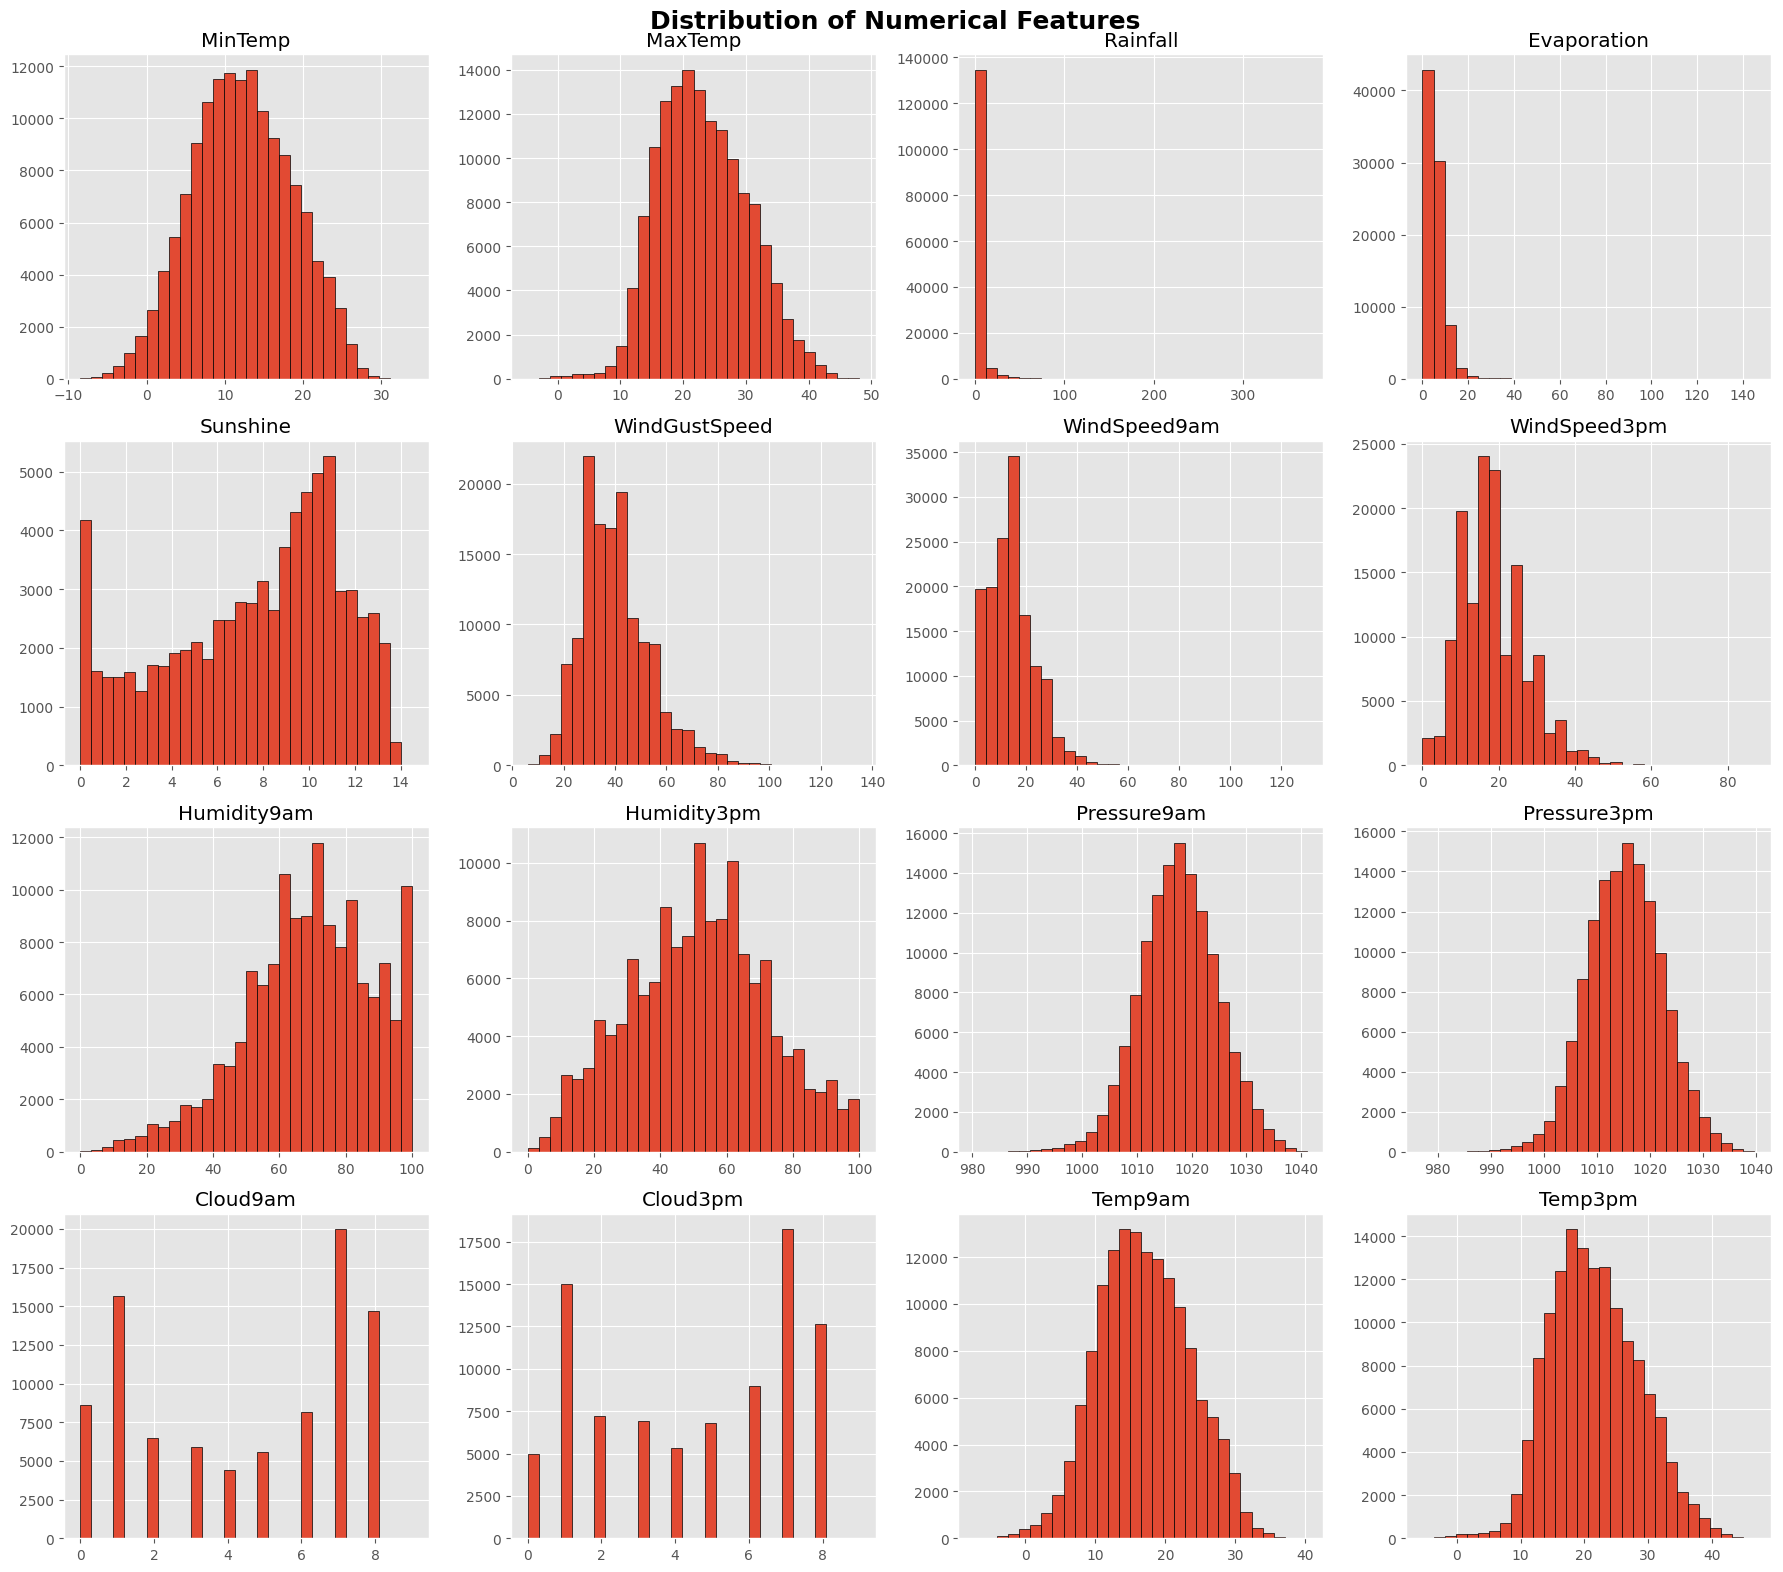

In [91]:
# ==========================================================
# Distribution of Numerical Features
# ==========================================================

df[numerical_features].hist(
    figsize=(18,16),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Analisis Outlier

In [92]:
# ==========================================================
# Outlier Analysis
# ==========================================================

outlier_features = [
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity3pm",
    "Pressure3pm",
    "Temp3pm"
]

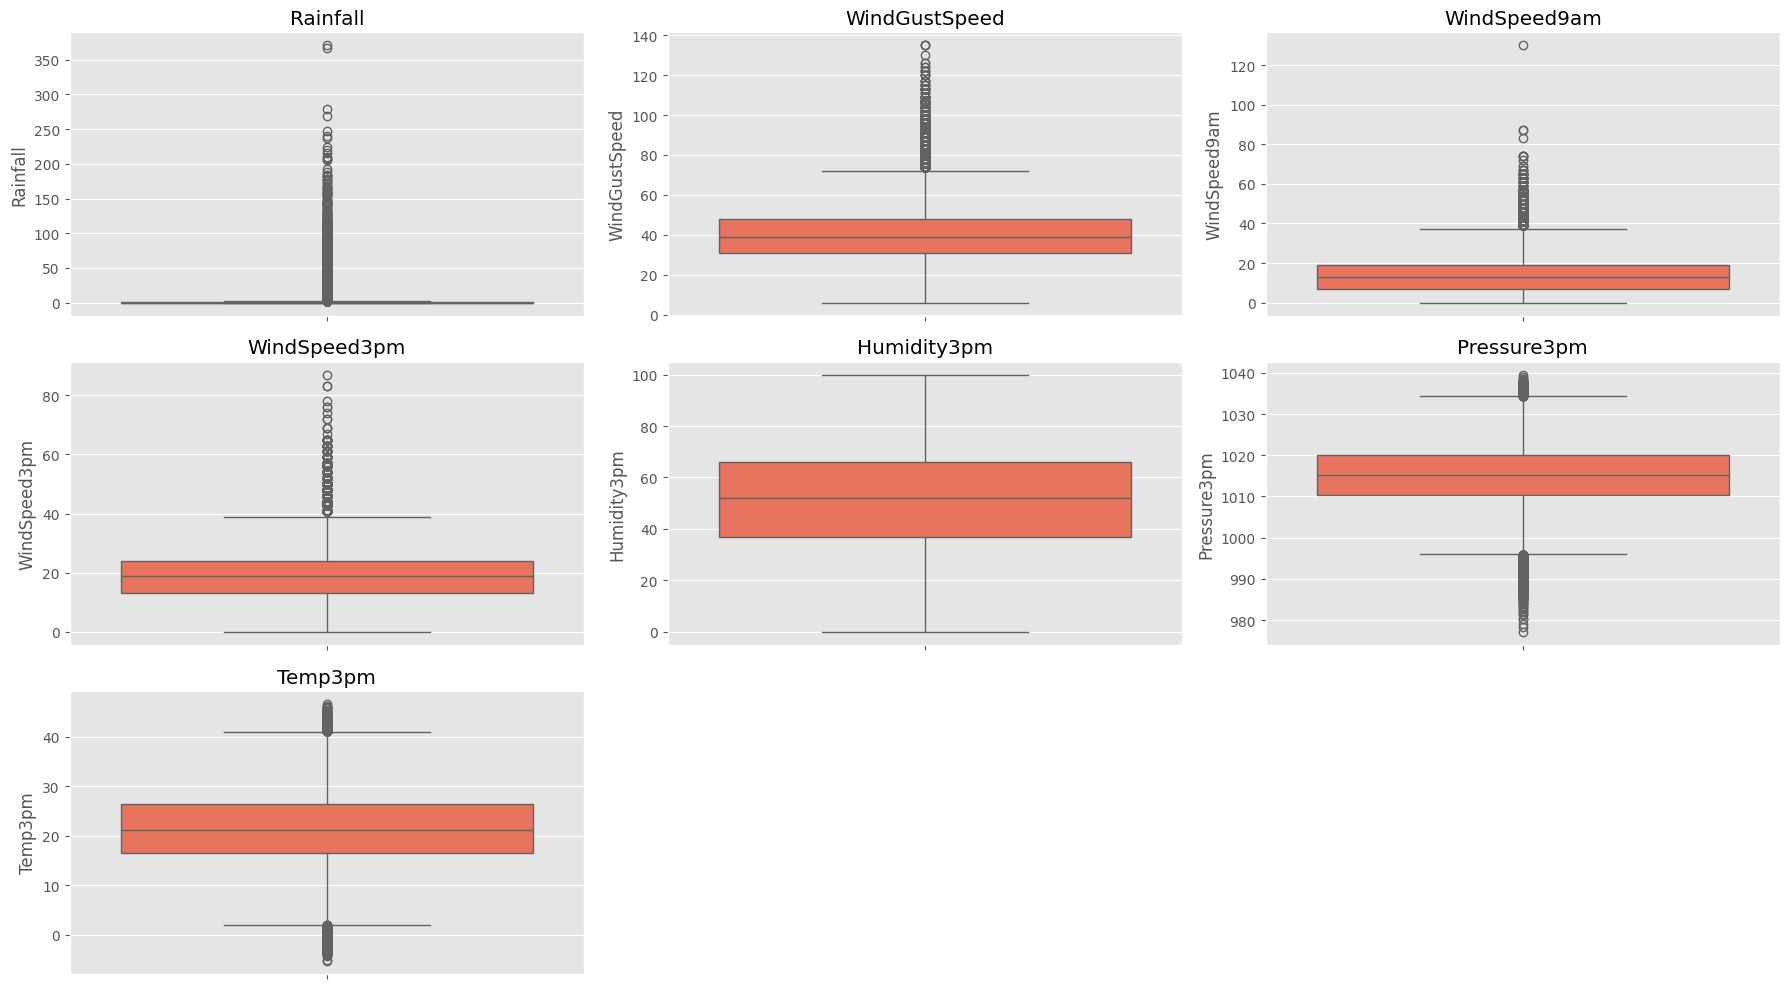

In [93]:
plt.figure(figsize=(18,10))

for i, col in enumerate(outlier_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color="tomato")
    plt.title(col)

plt.tight_layout()
plt.show()

## Analisis Korelasi

In [94]:
# Encoding
df_corr = df.copy()

df_corr["RainTomorrow"] = df_corr["RainTomorrow"].map({
    "No":0,
    "Yes":1
})

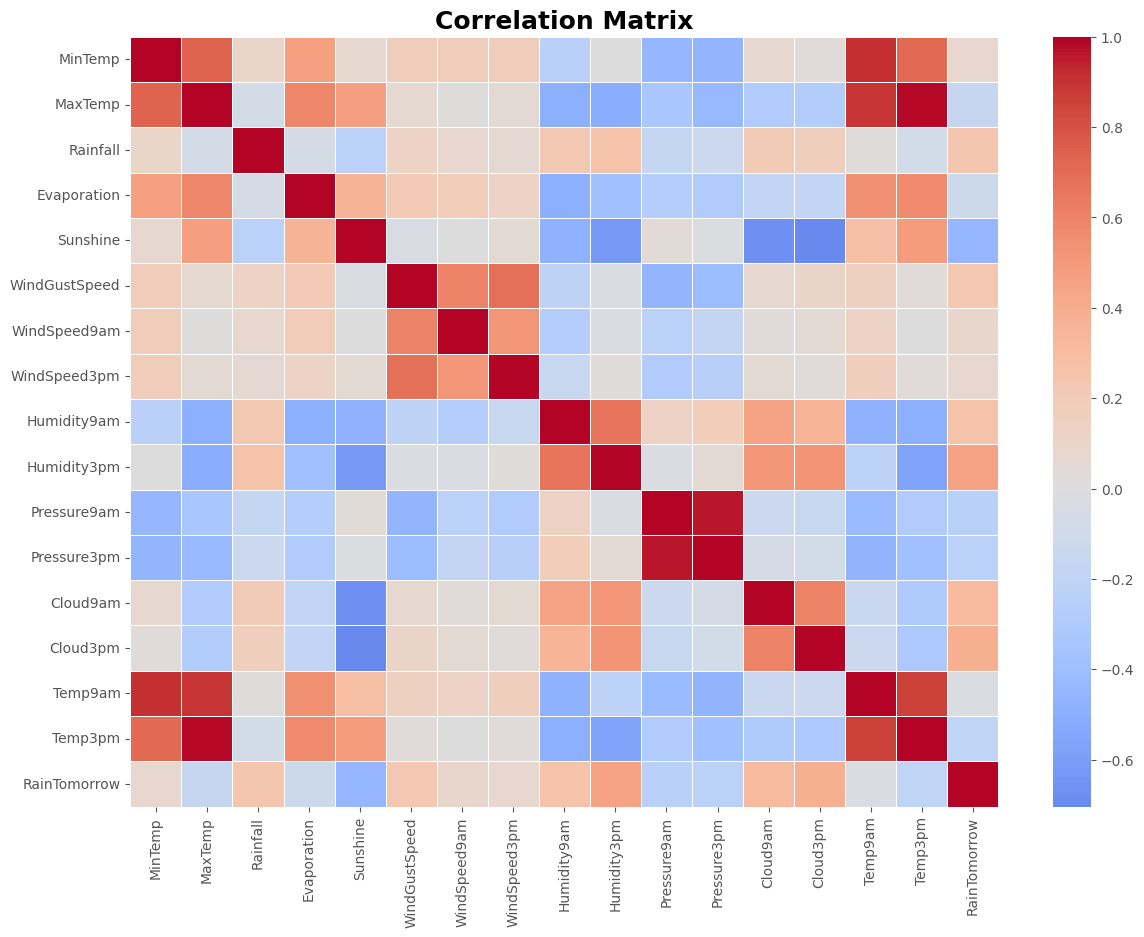

In [95]:
corr = df_corr.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [96]:
target_corr = (
    corr["RainTomorrow"]
    .drop("RainTomorrow")
    .sort_values(ascending=False)
)

target_corr

Humidity3pm      0.446160
Cloud3pm         0.381870
Cloud9am         0.317380
Humidity9am      0.257161
Rainfall         0.239032
WindGustSpeed    0.234010
WindSpeed9am     0.090995
WindSpeed3pm     0.087817
MinTemp          0.083936
Temp9am         -0.025691
Evaporation     -0.119285
MaxTemp         -0.159237
Temp3pm         -0.192424
Pressure3pm     -0.226031
Pressure9am     -0.246371
Sunshine        -0.450768
Name: RainTomorrow, dtype: float64

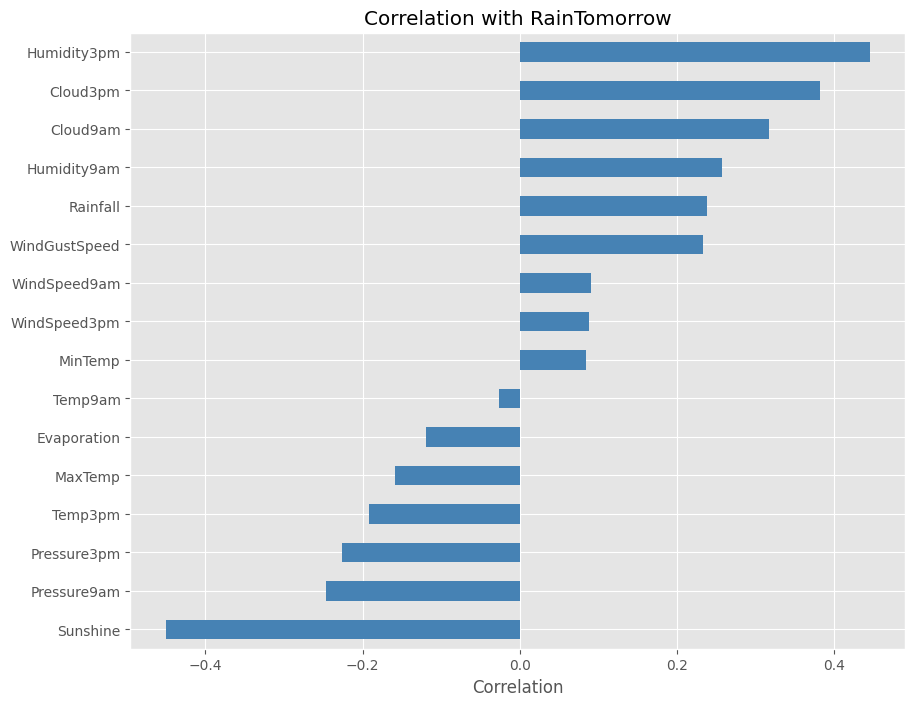

In [97]:
plt.figure(figsize=(10,8))

target_corr.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Correlation with RainTomorrow")
plt.xlabel("Correlation")

plt.show()

# Data Cleaning & Preprocessing

Tahap ini bertujuan untuk membersihkan dataset dan mempersiapkannya sebelum digunakan pada proses pemodelan machine learning. Proses meliputi penanganan missing value, feature engineering, encoding, serta pembagian data menjadi data latih dan data uji.

In [98]:
# ==========================================================
# Create Modeling Dataset
# ==========================================================

df_model = df.copy()

print("Shape :", df_model.shape)

Shape : (145460, 23)


In [99]:
# ==========================================================
# Remove Missing Target
# ==========================================================

print("Before :", df_model.shape)

df_model = df_model.dropna(subset=["RainTomorrow"])

print("After  :", df_model.shape)

Before : (145460, 23)
After  : (142193, 23)


In [100]:
# ==========================================================
# Encode Target
# ==========================================================

df_model["RainTomorrow"] = df_model["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

In [101]:
df_model["RainTomorrow"].value_counts()

RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

In [102]:
# ==========================================================
# Split Feature & Target
# ==========================================================

X = df_model.drop("RainTomorrow", axis=1)

y = df_model["RainTomorrow"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (142193, 22)
Target Shape  : (142193,)


In [103]:
# ==========================================================
# Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (113754, 22)
Test  : (28439, 22)


In [104]:
# ==========================================================
# Feature Types
# ==========================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical :", len(numerical_features))
print(numerical_features)

print()

print("Categorical :", len(categorical_features))
print(categorical_features)

Numerical : 16
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Categorical : 6
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


# Feature Engineering

Pada tahap ini dibuat beberapa fitur baru berdasarkan pengetahuan domain (domain knowledge) di bidang meteorologi. Tujuannya adalah membantu model mengenali pola yang tidak secara langsung terlihat dari fitur asli.

Feature 1 — Temperature Range

In [ ]:
# ==========================================================
# Feature Engineering
# ==========================================================

# Selisih suhu maksimum dan minimum, Semakin besar selisih suhu, biasanya cuaca lebih cerah.
X_train = X_train.copy()
X_test = X_test.copy()

X_train["TempRange"] = X_train["MaxTemp"] - X_train["MinTemp"]
X_test["TempRange"] = X_test["MaxTemp"] - X_test["MinTemp"]

Feature 2 — Pressure Difference

In [106]:
# Kalau tekanan turun menuju sore hari, sering menjadi tanda cuaca memburuk.
X_train["PressureDiff"] = (
    X_train["Pressure3pm"] -
    X_train["Pressure9am"]
)

X_test["PressureDiff"] = (
    X_test["Pressure3pm"] -
    X_test["Pressure9am"]
)

Feature 3 — Humidity Difference

In [107]:
X_train["HumidityDiff"] = (
    X_train["Humidity3pm"] -
    X_train["Humidity9am"]
)

X_test["HumidityDiff"] = (
    X_test["Humidity3pm"] -
    X_test["Humidity9am"]
)

Feature 4 — Average Temperature

In [108]:
X_train["AvgTemp"] = (
    X_train["MaxTemp"] +
    X_train["MinTemp"]
) / 2

X_test["AvgTemp"] = (
    X_test["MaxTemp"] +
    X_test["MinTemp"]
) / 2

Feature 5 — Average Pressure

In [113]:
X_train["AvgPressure"] = (
    X_train["Pressure9am"] +
    X_train["Pressure3pm"]
) / 2

X_test["AvgPressure"] = (
    X_test["Pressure9am"] +
    X_test["Pressure3pm"]
) / 2

Feature 6 — Average Humidity

In [114]:
X_train["AvgHumidity"] = (
    X_train["Humidity9am"] +
    X_train["Humidity3pm"]
) / 2

X_test["AvgHumidity"] = (
    X_test["Humidity9am"] +
    X_test["Humidity3pm"]
) / 2

Feature 7 — Wind Speed Difference

In [115]:
X_train["WindSpeedDiff"] = (
    X_train["WindSpeed3pm"] -
    X_train["WindSpeed9am"]
)

X_test["WindSpeedDiff"] = (
    X_test["WindSpeed3pm"] -
    X_test["WindSpeed9am"]
)

In [122]:
# ==========================================================
# Date Feature Engineering
# ==========================================================

for dataset in [X_train, X_test]:
    dataset["Date"] = pd.to_datetime(dataset["Date"])

    dataset["Year"] = dataset["Date"].dt.year
    dataset["Month"] = dataset["Date"].dt.month
    dataset["Day"] = dataset["Date"].dt.day

    dataset.drop(columns=["Date"], inplace=True)

In [123]:
new_features = [
    "TempRange",
    "PressureDiff",
    "HumidityDiff",
    "AvgTemp",
    "AvgPressure",
    "AvgHumidity",
    "WindSpeedDiff"
]

X_train[new_features].head()

,TempRange,PressureDiff,HumidityDiff,AvgTemp,AvgPressure,AvgHumidity,WindSpeedDiff
103642,15.5,-2.8,-32.0,27.05,1012.00,36.0,-8.0
18697,NaN,-1.5,NaN,NaN,1019.75,NaN,11.0
99305,10.4,-2.1,-20.0,18.20,1011.45,54.0,20.0
142981,8.4,-3.1,-21.0,29.20,1002.75,64.5,7.0
85572,10.5,-3.7,-13.0,20.55,1023.05,51.5,4.0


Update Fitur

In [124]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numerical Features : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 23
Categorical Features : 5


# Data Preprocessing Pipeline

Tahap ini membangun pipeline preprocessing menggunakan `ColumnTransformer`. Pipeline ini memastikan bahwa proses imputasi, encoding, dan scaling dilakukan secara konsisten pada data training maupun data testing sehingga menghindari data leakage.

In [125]:
# ==========================================================
# Numerical Pipeline
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [126]:
# ==========================================================
# Categorical Pipeline
# ==========================================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [127]:
# ==========================================================
# Column Transformer
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [121]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


# Baseline Modeling

In [128]:
# ==========================================================
# Evaluation Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("="*60)
    print(model.named_steps["classifier"].__class__.__name__)
    print("="*60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model.named_steps["classifier"].__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [129]:
# ==========================================================
# Logistic Regression
# ==========================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

result_lr = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

LogisticRegression
Accuracy  : 0.8506
Precision : 0.7371
Recall    : 0.5184
F1 Score  : 0.6087
ROC AUC   : 0.8732

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22064
           1       0.74      0.52      0.61      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



In [130]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_estimators=300
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

result_rf = evaluate_model(
    rf_model,
    X_test,
    y_test
)

RandomForestClassifier
Accuracy  : 0.8568
Precision : 0.7777
Recall    : 0.5059
F1 Score  : 0.6130
ROC AUC   : 0.8899

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22064
           1       0.78      0.51      0.61      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.73      0.76     28439
weighted avg       0.85      0.86      0.85     28439



In [131]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_estimators=300
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

result_xgb = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

XGBClassifier
Accuracy  : 0.8600
Precision : 0.7420
Recall    : 0.5757
F1 Score  : 0.6484
ROC AUC   : 0.8942

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     22064
           1       0.74      0.58      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.81      0.76      0.78     28439
weighted avg       0.85      0.86      0.85     28439



In [132]:
results = pd.DataFrame([
    result_lr,
    result_rf,
    result_xgb
])

results = results.sort_values(
    by="F1 Score",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBClassifier,0.860016,0.742014,0.575686,0.648353,0.894225
1,RandomForestClassifier,0.856816,0.777671,0.505882,0.613001,0.889922
0,LogisticRegression,0.850592,0.737065,0.518431,0.608712,0.873200


# Imbalance Handling 

Ini kenapa di akhir karena saya pengen mengetahui perbedaan sebelum dan sesudah SMOTE handling itu apakah terjadi perubahan yang signifikan atau tidak

In [138]:
def evaluate_model_preprocessed(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(model.__class__.__name__)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [133]:
from imblearn.over_sampling import SMOTE

# Transform data
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# SMOTE hanya untuk training
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_prepared,
    y_train
)

print("Before SMOTE :", y_train.value_counts())

print("\nAfter SMOTE :")
print(y_train_smote.value_counts())

Before SMOTE : RainTomorrow
0    88252
1    25502
Name: count, dtype: int64

After SMOTE :
RainTomorrow
0    88252
1    88252
Name: count, dtype: int64


In [139]:
# Re Train XGBoost

xgb_smote = XGBClassifier(
    random_state=42,
    n_estimators=300,
    eval_metric="logloss"
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

result_xgb_smote = evaluate_model_preprocessed(
    xgb_smote,
    X_test_prepared,
    y_test
)

XGBClassifier
Accuracy  : 0.8606
Precision : 0.7422
Recall    : 0.5793
F1 Score  : 0.6507
ROC AUC   : 0.8946

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     22064
           1       0.74      0.58      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.81      0.76      0.78     28439
weighted avg       0.85      0.86      0.85     28439



## Bandingkan Baseline vs SMOTE

In [141]:
comparison = pd.DataFrame([
    result_xgb,
    result_xgb_smote
])

comparison["Improvement Recall"] = (
    comparison["Recall"] -
    comparison.iloc[0]["Recall"]
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Improvement Recall
0,XGBClassifier,0.860016,0.742014,0.575686,0.648353,0.894225,0.000000
1,XGBClassifier,0.860579,0.742162,0.579294,0.650692,0.894625,0.003608


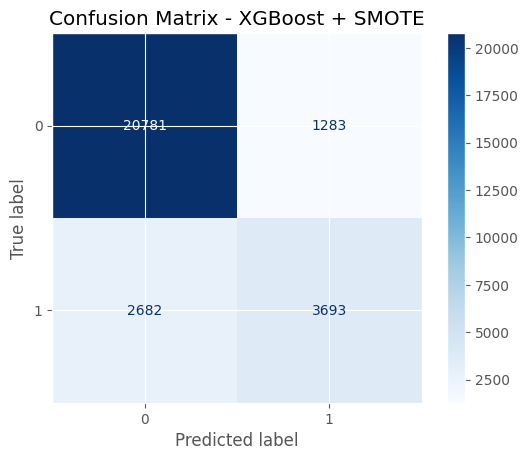

In [142]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

y_pred = xgb_smote.predict(X_test_prepared)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost + SMOTE")

plt.show()

# Hyperparameter Tuning

In [143]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "max_depth":[3,5,7,9],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,0.9,1],
    "colsample_bytree":[0.8,0.9,1],
    "n_estimators":[200,300,500]
}

In [144]:
# Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [145]:
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [146]:
search.best_params_

{'subsample': 1,
 'n_estimators': 200,
 'max_depth': 9,
 'learning_rate': 0.01,
 'colsample_bytree': 0.9}

In [148]:
# Train Best Model

best_xgb = search.best_estimator_

result_best = evaluate_model_preprocessed(
    best_xgb,
    X_test_prepared,
    y_test
)

XGBClassifier
Accuracy  : 0.8378
Precision : 0.6464
Recall    : 0.6100
F1 Score  : 0.6277
ROC AUC   : 0.8652

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     22064
           1       0.65      0.61      0.63      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.76      0.76     28439
weighted avg       0.83      0.84      0.84     28439



# Threshold Optimization

In [149]:
probs = best_xgb.predict_proba(X_test_prepared)[:,1]

In [150]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

thresholds = np.arange(0.2,0.8,0.02)

results=[]

for t in thresholds:

    pred=(probs>=t).astype(int)

    results.append([
        t,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

In [151]:
threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.344125,0.943686,0.504338
1,0.22,0.364893,0.923137,0.523041
2,0.24,0.384692,0.906667,0.540187
3,0.26,0.410159,0.884078,0.560350
4,0.28,0.431681,0.861804,0.575228
5,0.30,0.453984,0.841098,0.589684
6,0.32,0.480732,0.816000,0.605024
7,0.34,0.504086,0.793412,0.616491
8,0.36,0.525798,0.762510,0.622407
9,0.38,0.545730,0.734745,0.626287


In [153]:
threshold_df.sort_values(
    by="F1",
    ascending=False
).head()

,Threshold,Precision,Recall,F1
11,0.42,0.583300,0.691451,0.632788
12,0.44,0.599296,0.667922,0.631751
13,0.46,0.615133,0.647843,0.631064
14,0.48,0.630602,0.629020,0.629810
10,0.40,0.563352,0.712784,0.629319


> Justru setelah saya lakukan hyperparameter tuning dengan RandomSearchCV malah didapat nilai precision recall f1-score yang kurang

In [158]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame([
    result_lr,
    result_rf,
    result_xgb,
    result_xgb_smote
])

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison.insert(0, "Rank", range(1, len(comparison)+1))

comparison

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,XGBClassifier,0.860579,0.742162,0.579294,0.650692,0.894625
1,2,XGBClassifier,0.860016,0.742014,0.575686,0.648353,0.894225
2,3,RandomForestClassifier,0.856816,0.777671,0.505882,0.613001,0.889922
3,4,LogisticRegression,0.850592,0.737065,0.518431,0.608712,0.873200


In [159]:
print(search.best_params_)

{'subsample': 1, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


# CatBoost Modeling

ini menggunakan preprocessing yang berbeda dimana di model catboost ini saya tidak akan menggunakan One Hot Encoding karena akan banyak kehilangan keunggulan ketika pake One Hot Encoding ini

In [160]:
# ==========================================================
# Prepare Dataset for CatBoost
# ==========================================================

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

print(X_train_cat.shape)
print(X_test_cat.shape)

(113754, 31)
(28439, 31)


In [162]:
# Imputasi

from sklearn.impute import SimpleImputer

# ==========================================================
# Numerical Imputation
# ==========================================================

num_imputer = SimpleImputer(
    strategy="median"
)

X_train_cat[numerical_features] = num_imputer.fit_transform(
    X_train_cat[numerical_features]
)

X_test_cat[numerical_features] = num_imputer.transform(
    X_test_cat[numerical_features]
)

In [163]:
# ==========================================================
# Categorical Imputation
# ==========================================================

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_cat[categorical_features] = cat_imputer.fit_transform(
    X_train_cat[categorical_features]
)

X_test_cat[categorical_features] = cat_imputer.transform(
    X_test_cat[categorical_features]
)

In [164]:
# Cek Missing 
print(X_train_cat.isnull().sum().sum())

print(X_test_cat.isnull().sum().sum())

0
0


In [165]:
for col in categorical_features:
    X_train_cat[col] = X_train_cat[col].astype("category")
    X_test_cat[col] = X_test_cat[col].astype("category")

In [166]:
cat_features = [
    X_train_cat.columns.get_loc(col)
    for col in categorical_features
]

print(cat_features)

[0, 6, 8, 9, 20]


In [ ]:
# Class Weight

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

class_weights = [1, neg / pos]

print(class_weights)

[1, 3.4605913261704964]


> kenapa CatBoost pakai Class Weight bukan SMOTE 

In [174]:
# Model CatBoost

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=class_weights,
    random_seed=42,
    verbose=100
)

In [175]:
# Training

cat_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.7570652	total: 385ms	remaining: 3m 12s
100:	learn: 0.8019186	total: 27.9s	remaining: 1m 50s
200:	learn: 0.8176820	total: 54s	remaining: 1m 20s
300:	learn: 0.8291746	total: 1m 23s	remaining: 55.1s
400:	learn: 0.8390446	total: 1m 55s	remaining: 28.4s
499:	learn: 0.8467965	total: 2m 24s	remaining: 0us


CatBoostClassifier(class_weights=[1, 3.4605913261704964], depth=8, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [176]:
result_cat = evaluate_model_preprocessed(
    cat_model,
    X_test_cat,
    y_test
)

result_cat["Model"] = "CatBoost"

CatBoostClassifier
Accuracy  : 0.8252
Precision : 0.5794
Recall    : 0.8028
F1 Score  : 0.6731
ROC AUC   : 0.9032

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.83      0.88     22064
           1       0.58      0.80      0.67      6375

    accuracy                           0.83     28439
   macro avg       0.76      0.82      0.78     28439
weighted avg       0.86      0.83      0.83     28439



In [177]:
comparison = pd.DataFrame([
    result_lr,
    result_rf,
    result_xgb,
    result_xgb_smote,
    result_cat
])

comparison = (
    comparison
    .round(4)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

comparison.insert(0, "Rank", range(1, len(comparison) + 1))

comparison

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,CatBoost,0.8252,0.5794,0.8028,0.6731,0.9032
1,2,XGBClassifier,0.8606,0.7422,0.5793,0.6507,0.8946
2,3,XGBClassifier,0.8600,0.7420,0.5757,0.6484,0.8942
3,4,RandomForestClassifier,0.8568,0.7777,0.5059,0.6130,0.8899
4,5,LogisticRegression,0.8506,0.7371,0.5184,0.6087,0.8732
